In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import json
import pickle
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, classification_report

DATA_DIR = '/content/drive/MyDrive/MIRAGE/data/raw/GSE98320'

clean_df = pd.read_csv(f'{DATA_DIR}/gse98320_master_pathology_labels.csv')
gene_expr_matrix = pd.read_parquet(f'{DATA_DIR}/gse98320_gene_expression.parquet')

with open(f'{DATA_DIR}/selected_genes_per_fold_k1000.json', 'r') as f:
    selected_genes_per_fold = json.load(f)

with open(f'{DATA_DIR}/classical_baseline_results.pkl', 'rb') as f:
    model_results = pickle.load(f)

print("Master table shape:", clean_df.shape)
print("Loaded models:", list(model_results.keys()))

Mounted at /content/drive
Master table shape: (1208, 20)
Loaded models: ['LASSO', 'Ridge', 'SVM', 'Random Forest', 'XGBoost', 'MLP']


In [2]:
banff_cols = ['g', 'cg', 'i', 'ci', 't', 'ct', 'v', 'cv', 'ah', 'ptc', 'c4d_ordinal']

def preprocess_pathology_fold(clean_df, banff_cols, train_idx, val_idx):
    train_df = clean_df.loc[train_idx, banff_cols].copy()
    val_df = clean_df.loc[val_idx, banff_cols].copy()

    for col in banff_cols:
        train_df[f'{col}_was_missing'] = train_df[col].isna().astype(int)
        val_df[f'{col}_was_missing'] = val_df[col].isna().astype(int)

    medians = train_df[banff_cols].median()
    for col in banff_cols:
        train_df[col] = train_df[col].fillna(medians[col])
        val_df[col] = val_df[col].fillna(medians[col])

    return train_df, val_df, medians


fold_data = {}

for fold in range(5):
    train_idx = clean_df[clean_df['cv_fold'] != fold].index
    val_idx = clean_df[clean_df['cv_fold'] == fold].index

    path_train, path_val, medians = preprocess_pathology_fold(clean_df, banff_cols, train_idx, val_idx)

    train_gsms = clean_df.loc[train_idx, 'GSM'].values
    val_gsms = clean_df.loc[val_idx, 'GSM'].values

    gene_train_raw = gene_expr_matrix[train_gsms].T
    gene_val_raw = gene_expr_matrix[val_gsms].T

    gene_means = gene_train_raw.mean(axis=0)
    gene_stds = gene_train_raw.std(axis=0).replace(0, 1)

    gene_train_scaled = (gene_train_raw - gene_means) / gene_stds
    gene_val_scaled = (gene_val_raw - gene_means) / gene_stds

    fold_genes = selected_genes_per_fold[str(fold)]
    gene_train_selected = gene_train_scaled[fold_genes]
    gene_val_selected = gene_val_scaled[fold_genes]

    y_train = clean_df.loc[train_idx, 'mirage_label'].values
    y_val = clean_df.loc[val_idx, 'mirage_label'].values

    # Concatenate: gene expression (1000 cols) + pathology (22 cols) = 1022 total features
    # Reset indices so pd.concat aligns positionally, not by original clean_df index
    combined_train = pd.concat([
        gene_train_selected.reset_index(drop=True),
        path_train.reset_index(drop=True)
    ], axis=1)
    combined_val = pd.concat([
        gene_val_selected.reset_index(drop=True),
        path_val.reset_index(drop=True)
    ], axis=1)

    fold_data[fold] = {
        'gene_train': gene_train_selected, 'gene_val': gene_val_selected,
        'path_train': path_train, 'path_val': path_val,
        'combined_train': combined_train, 'combined_val': combined_val,
        'y_train': y_train, 'y_val': y_val,
        'train_gsms': train_gsms, 'val_gsms': val_gsms,
    }

    print(f"Fold {fold}: combined_train shape={combined_train.shape}, combined_val shape={combined_val.shape}")

Fold 0: combined_train shape=(966, 1022), combined_val shape=(242, 1022)
Fold 1: combined_train shape=(966, 1022), combined_val shape=(242, 1022)
Fold 2: combined_train shape=(967, 1022), combined_val shape=(241, 1022)
Fold 3: combined_train shape=(967, 1022), combined_val shape=(241, 1022)
Fold 4: combined_train shape=(966, 1022), combined_val shape=(242, 1022)


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

le = LabelEncoder()
le.fit(['NR', 'TCMR', 'ABMR', 'Mixed'])

class GeneMLP(nn.Module):
    def __init__(self, input_dim, hidden_dims, dropout, num_classes=4):
        super().__init__()
        layers = []
        prev_dim = input_dim
        for h in hidden_dims:
            layers.append(nn.Linear(prev_dim, h))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            prev_dim = h
        layers.append(nn.Linear(prev_dim, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


def train_mlp_final(fold, data_key_train, data_key_val, hidden_dims, dropout, lr, weight_decay,
                     epochs=300, patience=25, seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)

    X_train = torch.tensor(fold_data[fold][data_key_train].values, dtype=torch.float32)
    X_val = torch.tensor(fold_data[fold][data_key_val].values, dtype=torch.float32)
    y_train_enc = le.transform(fold_data[fold]['y_train'])
    y_val_enc = le.transform(fold_data[fold]['y_val'])
    y_train_t = torch.tensor(y_train_enc, dtype=torch.long)

    class_weights = compute_class_weight('balanced', classes=np.arange(4), y=y_train_enc)
    class_weights_t = torch.tensor(class_weights, dtype=torch.float32).to(device)

    g = torch.Generator()
    g.manual_seed(seed)
    train_ds = TensorDataset(X_train, y_train_t)
    train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, generator=g)

    model = GeneMLP(input_dim=X_train.shape[1], hidden_dims=hidden_dims, dropout=dropout).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.CrossEntropyLoss(weight=class_weights_t)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=8)

    X_val_dev = X_val.to(device)
    best_val_f1, best_state, epochs_no_improve = -1, None, 0

    for epoch in range(epochs):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            val_preds = model(X_val_dev).argmax(dim=1).cpu().numpy()
        val_f1 = f1_score(y_val_enc, val_preds, average='macro')
        scheduler.step(val_f1)

        if val_f1 > best_val_f1:
            best_val_f1, best_state, epochs_no_improve = val_f1, {k: v.clone() for k, v in model.state_dict().items()}, 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                break

    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        final_preds_enc = model(X_val_dev).argmax(dim=1).cpu().numpy()
    final_preds = le.inverse_transform(final_preds_enc)

    return best_val_f1, final_preds, fold_data[fold]['y_val']


# Run multimodal MLP with the SAME best config found for gene-only (starting point, will re-tune after)
multimodal_fold_scores = []
multimodal_predictions = []

for fold in range(5):
    val_f1, preds, y_val = train_mlp_final(
        fold, 'combined_train', 'combined_val',
        hidden_dims=[256, 128, 64], dropout=0.2, lr=3e-4, weight_decay=1e-4
    )
    multimodal_fold_scores.append(val_f1)
    multimodal_predictions.append((y_val, preds))
    print(f"Fold {fold}: val macro-F1={val_f1:.4f}")

print(f"\nMultimodal MLP (concat, gene-tuned hyperparams): mean macro-F1={np.mean(multimodal_fold_scores):.4f} "
      f"(+/- {np.std(multimodal_fold_scores):.4f})")
print(f"Compare to gene-only MLP: mean macro-F1=0.8073")

Using device: cuda
Fold 0: val macro-F1=0.8323
Fold 1: val macro-F1=0.8098
Fold 2: val macro-F1=0.7893
Fold 3: val macro-F1=0.7672
Fold 4: val macro-F1=0.8840

Multimodal MLP (concat, gene-tuned hyperparams): mean macro-F1=0.8165 (+/- 0.0400)
Compare to gene-only MLP: mean macro-F1=0.8073


dropout=0.2: macro-F1=0.8165 (+/-0.0400), accuracy=0.8824 (+/-0.0186)
dropout=0.3: macro-F1=0.8011 (+/-0.0311), accuracy=0.8766 (+/-0.0169)
dropout=0.4: macro-F1=0.7981 (+/-0.0256), accuracy=0.8758 (+/-0.0196)
dropout=0.5: macro-F1=0.7971 (+/-0.0213), accuracy=0.8708 (+/-0.0198)


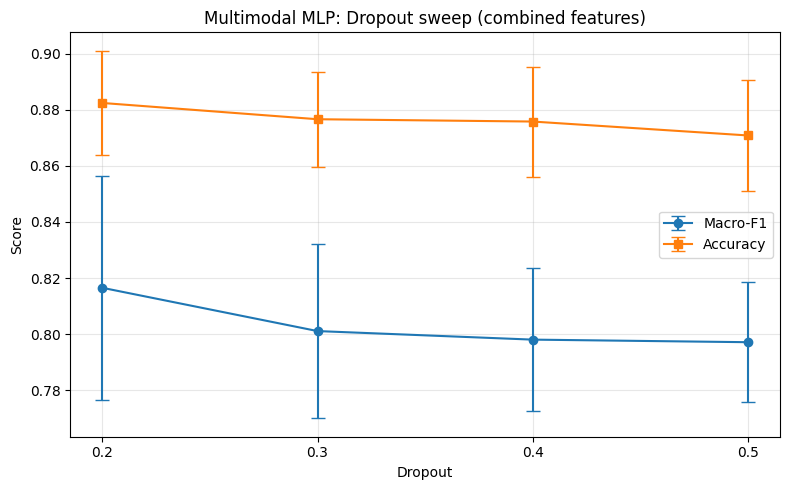

In [4]:
def run_mlp_config_across_folds(data_key_train, data_key_val, hidden_dims, dropout, lr, weight_decay):
    fold_f1_scores = []
    fold_acc_scores = []
    fold_predictions = []
    for fold in range(5):
        val_f1, preds, y_val = train_mlp_final(fold, data_key_train, data_key_val, hidden_dims, dropout, lr, weight_decay)
        acc = accuracy_score(y_val, preds)
        fold_f1_scores.append(val_f1)
        fold_acc_scores.append(acc)
        fold_predictions.append((y_val, preds))
    return np.mean(fold_f1_scores), np.std(fold_f1_scores), np.mean(fold_acc_scores), np.std(fold_acc_scores), fold_f1_scores, fold_predictions


# Sweep dropout for the combined (1022-dim) input
dropout_values = [0.2, 0.3, 0.4, 0.5]

dropout_results_mm = []
for dropout in dropout_values:
    mean_f1, std_f1, mean_acc, std_acc, _, _ = run_mlp_config_across_folds(
        'combined_train', 'combined_val', [256, 128, 64], dropout, 3e-4, 1e-4
    )
    dropout_results_mm.append({
        'dropout': dropout, 'mean_macro_f1': mean_f1, 'std_macro_f1': std_f1,
        'mean_accuracy': mean_acc, 'std_accuracy': std_acc
    })
    print(f"dropout={dropout}: macro-F1={mean_f1:.4f} (+/-{std_f1:.4f}), accuracy={mean_acc:.4f} (+/-{std_acc:.4f})")

dropout_mm_df = pd.DataFrame(dropout_results_mm)

fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(dropout_mm_df['dropout'].astype(str), dropout_mm_df['mean_macro_f1'],
            yerr=dropout_mm_df['std_macro_f1'], marker='o', capsize=5, label='Macro-F1')
ax.errorbar(dropout_mm_df['dropout'].astype(str), dropout_mm_df['mean_accuracy'],
            yerr=dropout_mm_df['std_accuracy'], marker='s', capsize=5, label='Accuracy')
ax.set_xlabel('Dropout')
ax.set_ylabel('Score')
ax.set_title('Multimodal MLP: Dropout sweep (combined features)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

medium [128,64]: macro-F1=0.7981 (+/-0.0285), accuracy=0.8808 (+/-0.0191)
large [256,128,64]: macro-F1=0.8165 (+/-0.0400), accuracy=0.8824 (+/-0.0186)
xlarge [512,256,128,64]: macro-F1=0.8082 (+/-0.0325), accuracy=0.8783 (+/-0.0202)


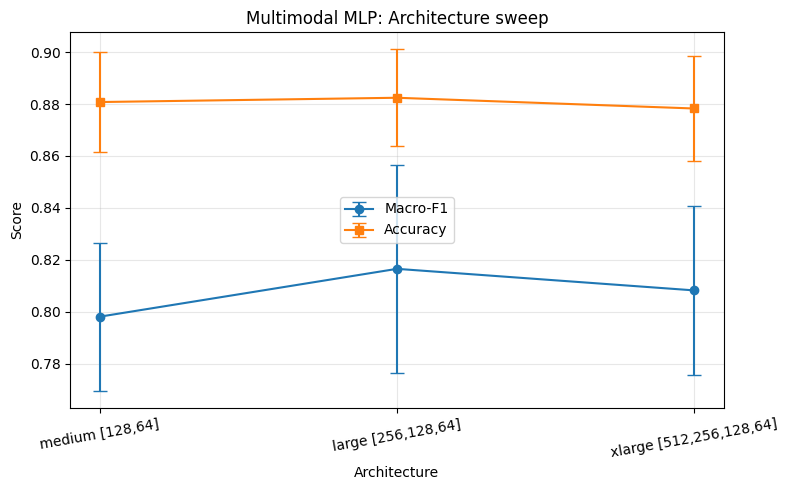

In [5]:
architectures = {
    'medium [128,64]': [128, 64],
    'large [256,128,64]': [256, 128, 64],
    'xlarge [512,256,128,64]': [512, 256, 128, 64],
}

arch_results_mm = []
for name, hidden_dims in architectures.items():
    mean_f1, std_f1, mean_acc, std_acc, _, _ = run_mlp_config_across_folds(
        'combined_train', 'combined_val', hidden_dims, 0.2, 3e-4, 1e-4
    )
    arch_results_mm.append({
        'architecture': name, 'mean_macro_f1': mean_f1, 'std_macro_f1': std_f1,
        'mean_accuracy': mean_acc, 'std_accuracy': std_acc
    })
    print(f"{name}: macro-F1={mean_f1:.4f} (+/-{std_f1:.4f}), accuracy={mean_acc:.4f} (+/-{std_acc:.4f})")

arch_mm_df = pd.DataFrame(arch_results_mm)

fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(arch_mm_df['architecture'], arch_mm_df['mean_macro_f1'],
            yerr=arch_mm_df['std_macro_f1'], marker='o', capsize=5, label='Macro-F1')
ax.errorbar(arch_mm_df['architecture'], arch_mm_df['mean_accuracy'],
            yerr=arch_mm_df['std_accuracy'], marker='s', capsize=5, label='Accuracy')
ax.set_xlabel('Architecture')
ax.set_ylabel('Score')
ax.set_title('Multimodal MLP: Architecture sweep')
ax.legend()
ax.grid(True, alpha=0.3)
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

In [6]:
def preprocess_pathology_fold_standardized(clean_df, banff_cols, train_idx, val_idx):
    """Same as before, but also z-score standardizes the ordinal features after imputation."""
    train_df = clean_df.loc[train_idx, banff_cols].copy()
    val_df = clean_df.loc[val_idx, banff_cols].copy()

    for col in banff_cols:
        train_df[f'{col}_was_missing'] = train_df[col].isna().astype(int)
        val_df[f'{col}_was_missing'] = val_df[col].isna().astype(int)

    medians = train_df[banff_cols].median()
    for col in banff_cols:
        train_df[col] = train_df[col].fillna(medians[col])
        val_df[col] = val_df[col].fillna(medians[col])

    # NEW: standardize the ordinal Banff columns (not the binary missingness indicators)
    means = train_df[banff_cols].mean()
    stds = train_df[banff_cols].std().replace(0, 1)
    for col in banff_cols:
        train_df[col] = (train_df[col] - means[col]) / stds[col]
        val_df[col] = (val_df[col] - means[col]) / stds[col]

    return train_df, val_df, medians, means, stds


for fold in range(5):
    train_idx = clean_df[clean_df['cv_fold'] != fold].index
    val_idx = clean_df[clean_df['cv_fold'] == fold].index

    path_train_std, path_val_std, _, _, _ = preprocess_pathology_fold_standardized(clean_df, banff_cols, train_idx, val_idx)

    gene_train_selected = fold_data[fold]['gene_train']
    gene_val_selected = fold_data[fold]['gene_val']

    combined_train_std = pd.concat([
        gene_train_selected.reset_index(drop=True),
        path_train_std.reset_index(drop=True)
    ], axis=1)
    combined_val_std = pd.concat([
        gene_val_selected.reset_index(drop=True),
        path_val_std.reset_index(drop=True)
    ], axis=1)

    fold_data[fold]['combined_train_std'] = combined_train_std
    fold_data[fold]['combined_val_std'] = combined_val_std

print("Standardized combined features added to fold_data.")
print("Fold 0 combined_train_std shape:", fold_data[0]['combined_train_std'].shape)

mean_f1, std_f1, mean_acc, std_acc, _, _ = run_mlp_config_across_folds(
    'combined_train_std', 'combined_val_std', [256, 128, 64], 0.2, 3e-4, 1e-4
)
print(f"\nWith standardized pathology: macro-F1={mean_f1:.4f} (+/-{std_f1:.4f}), accuracy={mean_acc:.4f} (+/-{std_acc:.4f})")
print(f"Compare to unstandardized pathology: macro-F1=0.8165, accuracy=0.8824")

Standardized combined features added to fold_data.
Fold 0 combined_train_std shape: (966, 1022)

With standardized pathology: macro-F1=0.8076 (+/-0.0413), accuracy=0.8857 (+/-0.0183)
Compare to unstandardized pathology: macro-F1=0.8165, accuracy=0.8824


In [7]:
class FocalLoss(nn.Module):
    def __init__(self, alpha, gamma=2.0):
        super().__init__()
        self.alpha = alpha  # per-class weights (same role as class_weight)
        self.gamma = gamma  # focusing parameter; higher = more focus on hard examples

    def forward(self, inputs, targets):
        ce_loss = nn.functional.cross_entropy(inputs, targets, weight=self.alpha, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        return focal_loss.mean()


def train_mlp_focal_loss(fold, data_key_train, data_key_val, hidden_dims, dropout, lr, weight_decay, gamma,
                          epochs=300, patience=25, seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)

    X_train = torch.tensor(fold_data[fold][data_key_train].values, dtype=torch.float32)
    X_val = torch.tensor(fold_data[fold][data_key_val].values, dtype=torch.float32)
    y_train_enc = le.transform(fold_data[fold]['y_train'])
    y_val_enc = le.transform(fold_data[fold]['y_val'])
    y_train_t = torch.tensor(y_train_enc, dtype=torch.long)

    class_weights = compute_class_weight('balanced', classes=np.arange(4), y=y_train_enc)
    class_weights_t = torch.tensor(class_weights, dtype=torch.float32).to(device)

    g = torch.Generator()
    g.manual_seed(seed)
    train_ds = TensorDataset(X_train, y_train_t)
    train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, generator=g)

    model = GeneMLP(input_dim=X_train.shape[1], hidden_dims=hidden_dims, dropout=dropout).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = FocalLoss(alpha=class_weights_t, gamma=gamma)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=8)

    X_val_dev = X_val.to(device)
    best_val_f1, best_state, epochs_no_improve = -1, None, 0

    for epoch in range(epochs):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            val_preds = model(X_val_dev).argmax(dim=1).cpu().numpy()
        val_f1 = f1_score(y_val_enc, val_preds, average='macro')
        scheduler.step(val_f1)

        if val_f1 > best_val_f1:
            best_val_f1, best_state, epochs_no_improve = val_f1, {k: v.clone() for k, v in model.state_dict().items()}, 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                break

    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        final_preds_enc = model(X_val_dev).argmax(dim=1).cpu().numpy()
    final_preds = le.inverse_transform(final_preds_enc)
    acc = accuracy_score(fold_data[fold]['y_val'], final_preds)

    return best_val_f1, acc, final_preds, fold_data[fold]['y_val']


gamma_values = [1.0, 2.0, 3.0]
focal_results = []

for gamma in gamma_values:
    fold_f1s, fold_accs = [], []
    for fold in range(5):
        val_f1, acc, preds, y_val = train_mlp_focal_loss(
            fold, 'combined_train', 'combined_val', [256, 128, 64], 0.2, 3e-4, 1e-4, gamma
        )
        fold_f1s.append(val_f1)
        fold_accs.append(acc)
    mean_f1, std_f1 = np.mean(fold_f1s), np.std(fold_f1s)
    mean_acc, std_acc = np.mean(fold_accs), np.std(fold_accs)
    focal_results.append({'gamma': gamma, 'mean_macro_f1': mean_f1, 'std_macro_f1': std_f1, 'mean_accuracy': mean_acc, 'std_accuracy': std_acc})
    print(f"gamma={gamma}: macro-F1={mean_f1:.4f} (+/-{std_f1:.4f}), accuracy={mean_acc:.4f} (+/-{std_acc:.4f})")

print(f"\nCompare to weighted cross-entropy baseline: macro-F1=0.8165, accuracy=0.8824")

gamma=1.0: macro-F1=0.7951 (+/-0.0286), accuracy=0.8775 (+/-0.0079)
gamma=2.0: macro-F1=0.7960 (+/-0.0179), accuracy=0.8742 (+/-0.0144)
gamma=3.0: macro-F1=0.7797 (+/-0.0094), accuracy=0.8568 (+/-0.0122)

Compare to weighted cross-entropy baseline: macro-F1=0.8165, accuracy=0.8824


In [8]:
def train_mlp_get_probs(fold, data_key_train, data_key_val, hidden_dims, dropout, lr, weight_decay, seed,
                         epochs=300, patience=25):
    torch.manual_seed(seed)
    np.random.seed(seed)

    X_train = torch.tensor(fold_data[fold][data_key_train].values, dtype=torch.float32)
    X_val = torch.tensor(fold_data[fold][data_key_val].values, dtype=torch.float32)
    y_train_enc = le.transform(fold_data[fold]['y_train'])
    y_val_enc = le.transform(fold_data[fold]['y_val'])
    y_train_t = torch.tensor(y_train_enc, dtype=torch.long)

    class_weights = compute_class_weight('balanced', classes=np.arange(4), y=y_train_enc)
    class_weights_t = torch.tensor(class_weights, dtype=torch.float32).to(device)

    g = torch.Generator()
    g.manual_seed(seed)
    train_ds = TensorDataset(X_train, y_train_t)
    train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, generator=g)

    model = GeneMLP(input_dim=X_train.shape[1], hidden_dims=hidden_dims, dropout=dropout).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.CrossEntropyLoss(weight=class_weights_t)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=8)

    X_val_dev = X_val.to(device)
    best_val_f1, best_state, epochs_no_improve = -1, None, 0

    for epoch in range(epochs):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            val_preds = model(X_val_dev).argmax(dim=1).cpu().numpy()
        val_f1 = f1_score(y_val_enc, val_preds, average='macro')
        scheduler.step(val_f1)

        if val_f1 > best_val_f1:
            best_val_f1, best_state, epochs_no_improve = val_f1, {k: v.clone() for k, v in model.state_dict().items()}, 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                break

    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        val_probs = torch.softmax(model(X_val_dev), dim=1).cpu().numpy()
    return val_probs


seeds = [42, 123, 7, 2024, 99]

ensemble_fold_f1s = []
ensemble_fold_accs = []

for fold in range(5):
    all_probs = []
    for seed in seeds:
        probs = train_mlp_get_probs(fold, 'combined_train', 'combined_val', [256, 128, 64], 0.2, 3e-4, 1e-4, seed)
        all_probs.append(probs)

    avg_probs = np.mean(all_probs, axis=0)
    ensemble_preds_enc = avg_probs.argmax(axis=1)
    ensemble_preds = le.inverse_transform(ensemble_preds_enc)

    y_val = fold_data[fold]['y_val']
    f1 = f1_score(y_val, ensemble_preds, average='macro')
    acc = accuracy_score(y_val, ensemble_preds)
    ensemble_fold_f1s.append(f1)
    ensemble_fold_accs.append(acc)
    print(f"Fold {fold}: ensemble macro-F1={f1:.4f}, accuracy={acc:.4f}")

print(f"\n5-seed ensemble: mean macro-F1={np.mean(ensemble_fold_f1s):.4f} (+/-{np.std(ensemble_fold_f1s):.4f}), "
      f"accuracy={np.mean(ensemble_fold_accs):.4f} (+/-{np.std(ensemble_fold_accs):.4f})")
print(f"Compare to single-seed: macro-F1=0.8165, accuracy=0.8824")

Fold 0: ensemble macro-F1=0.8157, accuracy=0.8884
Fold 1: ensemble macro-F1=0.8208, accuracy=0.9008
Fold 2: ensemble macro-F1=0.7935, accuracy=0.8506
Fold 3: ensemble macro-F1=0.7484, accuracy=0.8672
Fold 4: ensemble macro-F1=0.8599, accuracy=0.8843

5-seed ensemble: mean macro-F1=0.8076 (+/-0.0365), accuracy=0.8783 (+/-0.0175)
Compare to single-seed: macro-F1=0.8165, accuracy=0.8824


In [9]:
from sklearn.feature_selection import f_classif

def select_genes_two_stage(gene_train_df, y_train, variance_top_n=5000, k_final=1000):
    gene_variances = gene_train_df.var(axis=0)
    top_variance_genes = gene_variances.nlargest(variance_top_n).index
    X_stage1 = gene_train_df[top_variance_genes]
    f_scores, p_values = f_classif(X_stage1, y_train)
    f_score_series = pd.Series(f_scores, index=top_variance_genes)
    return f_score_series.nlargest(k_final).index.tolist()


k_values_mm = [250, 500, 1000, 1500]
k_mm_results = []

for k in k_values_mm:
    fold_f1s, fold_accs = [], []

    for fold in range(5):
        train_idx = clean_df[clean_df['cv_fold'] != fold].index
        val_idx = clean_df[clean_df['cv_fold'] == fold].index

        train_gsms = clean_df.loc[train_idx, 'GSM'].values
        val_gsms = clean_df.loc[val_idx, 'GSM'].values

        gene_train_raw = gene_expr_matrix[train_gsms].T
        gene_val_raw = gene_expr_matrix[val_gsms].T
        gene_means = gene_train_raw.mean(axis=0)
        gene_stds = gene_train_raw.std(axis=0).replace(0, 1)
        gene_train_scaled = (gene_train_raw - gene_means) / gene_stds
        gene_val_scaled = (gene_val_raw - gene_means) / gene_stds

        y_train_fold = clean_df.loc[train_idx, 'mirage_label'].values

        # Re-select genes at this K
        selected = select_genes_two_stage(gene_train_scaled, y_train_fold, variance_top_n=5000, k_final=k)
        gene_train_k = gene_train_scaled[selected]
        gene_val_k = gene_val_scaled[selected]

        path_train = fold_data[fold]['path_train']
        path_val = fold_data[fold]['path_val']

        combined_train_k = pd.concat([gene_train_k.reset_index(drop=True), path_train.reset_index(drop=True)], axis=1)
        combined_val_k = pd.concat([gene_val_k.reset_index(drop=True), path_val.reset_index(drop=True)], axis=1)

        temp_fold_data = {fold: {
            'combined_train_temp': combined_train_k, 'combined_val_temp': combined_val_k,
            'y_train': y_train_fold, 'y_val': clean_df.loc[val_idx, 'mirage_label'].values
        }}

        val_f1, preds, y_val = train_mlp_final(fold, 'combined_train_temp', 'combined_val_temp',
                                                 [256, 128, 64], 0.2, 3e-4, 1e-4)
        # Note: train_mlp_final expects fold_data[fold][...] — swap temporarily
        fold_data[fold]['combined_train_temp'] = combined_train_k
        fold_data[fold]['combined_val_temp'] = combined_val_k

        acc = accuracy_score(y_val, preds)
        fold_f1s.append(val_f1)
        fold_accs.append(acc)

    mean_f1, std_f1 = np.mean(fold_f1s), np.std(fold_f1s)
    mean_acc, std_acc = np.mean(fold_accs), np.std(fold_accs)
    k_mm_results.append({'k': k, 'mean_macro_f1': mean_f1, 'std_macro_f1': std_f1, 'mean_accuracy': mean_acc, 'std_accuracy': std_acc})
    print(f"K={k}: macro-F1={mean_f1:.4f} (+/-{std_f1:.4f}), accuracy={mean_acc:.4f} (+/-{std_acc:.4f})")

print(f"\nCompare to K=1000: macro-F1=0.8165, accuracy=0.8824")

KeyError: 'combined_train_temp'

In [10]:
k_values_mm = [250, 500, 1000, 1500]
k_mm_results = []

for k in k_values_mm:
    fold_f1s, fold_accs = [], []

    for fold in range(5):
        train_idx = clean_df[clean_df['cv_fold'] != fold].index
        val_idx = clean_df[clean_df['cv_fold'] == fold].index

        train_gsms = clean_df.loc[train_idx, 'GSM'].values
        val_gsms = clean_df.loc[val_idx, 'GSM'].values

        gene_train_raw = gene_expr_matrix[train_gsms].T
        gene_val_raw = gene_expr_matrix[val_gsms].T
        gene_means = gene_train_raw.mean(axis=0)
        gene_stds = gene_train_raw.std(axis=0).replace(0, 1)
        gene_train_scaled = (gene_train_raw - gene_means) / gene_stds
        gene_val_scaled = (gene_val_raw - gene_means) / gene_stds

        y_train_fold = clean_df.loc[train_idx, 'mirage_label'].values
        y_val_fold = clean_df.loc[val_idx, 'mirage_label'].values

        selected = select_genes_two_stage(gene_train_scaled, y_train_fold, variance_top_n=5000, k_final=k)
        gene_train_k = gene_train_scaled[selected]
        gene_val_k = gene_val_scaled[selected]

        path_train = fold_data[fold]['path_train']
        path_val = fold_data[fold]['path_val']

        combined_train_k = pd.concat([gene_train_k.reset_index(drop=True), path_train.reset_index(drop=True)], axis=1)
        combined_val_k = pd.concat([gene_val_k.reset_index(drop=True), path_val.reset_index(drop=True)], axis=1)

        # Set BEFORE calling train_mlp_final, and also update y_train/y_val for this fold
        fold_data[fold]['combined_train_temp'] = combined_train_k
        fold_data[fold]['combined_val_temp'] = combined_val_k
        fold_data[fold]['y_train'] = y_train_fold
        fold_data[fold]['y_val'] = y_val_fold

        val_f1, preds, y_val = train_mlp_final(fold, 'combined_train_temp', 'combined_val_temp',
                                                 [256, 128, 64], 0.2, 3e-4, 1e-4)

        acc = accuracy_score(y_val, preds)
        fold_f1s.append(val_f1)
        fold_accs.append(acc)

    mean_f1, std_f1 = np.mean(fold_f1s), np.std(fold_f1s)
    mean_acc, std_acc = np.mean(fold_accs), np.std(fold_accs)
    k_mm_results.append({'k': k, 'mean_macro_f1': mean_f1, 'std_macro_f1': std_f1, 'mean_accuracy': mean_acc, 'std_accuracy': std_acc})
    print(f"K={k}: macro-F1={mean_f1:.4f} (+/-{std_f1:.4f}), accuracy={mean_acc:.4f} (+/-{std_acc:.4f})")

print(f"\nCompare to K=1000: macro-F1=0.8165, accuracy=0.8824")

K=250: macro-F1=0.8149 (+/-0.0168), accuracy=0.8841 (+/-0.0161)
K=500: macro-F1=0.8446 (+/-0.0495), accuracy=0.8924 (+/-0.0213)
K=1000: macro-F1=0.8165 (+/-0.0400), accuracy=0.8824 (+/-0.0186)
K=1500: macro-F1=0.7827 (+/-0.0337), accuracy=0.8700 (+/-0.0173)

Compare to K=1000: macro-F1=0.8165, accuracy=0.8824


In [11]:
# Rebuild K=500 gene selection + combined features properly in fold_data (not just temp)
for fold in range(5):
    train_idx = clean_df[clean_df['cv_fold'] != fold].index
    val_idx = clean_df[clean_df['cv_fold'] == fold].index

    train_gsms = clean_df.loc[train_idx, 'GSM'].values
    val_gsms = clean_df.loc[val_idx, 'GSM'].values

    gene_train_raw = gene_expr_matrix[train_gsms].T
    gene_val_raw = gene_expr_matrix[val_gsms].T
    gene_means = gene_train_raw.mean(axis=0)
    gene_stds = gene_train_raw.std(axis=0).replace(0, 1)
    gene_train_scaled = (gene_train_raw - gene_means) / gene_stds
    gene_val_scaled = (gene_val_raw - gene_means) / gene_stds

    y_train_fold = fold_data[fold]['y_train']
    selected_k500 = select_genes_two_stage(gene_train_scaled, y_train_fold, variance_top_n=5000, k_final=500)

    gene_train_k500 = gene_train_scaled[selected_k500]
    gene_val_k500 = gene_val_scaled[selected_k500]

    path_train = fold_data[fold]['path_train']
    path_val = fold_data[fold]['path_val']

    fold_data[fold]['combined_train_k500'] = pd.concat(
        [gene_train_k500.reset_index(drop=True), path_train.reset_index(drop=True)], axis=1)
    fold_data[fold]['combined_val_k500'] = pd.concat(
        [gene_val_k500.reset_index(drop=True), path_val.reset_index(drop=True)], axis=1)

# Final multimodal model at K=500
multimodal_final_predictions = []
multimodal_final_f1s = []

for fold in range(5):
    val_f1, preds, y_val = train_mlp_final(fold, 'combined_train_k500', 'combined_val_k500',
                                             [256, 128, 64], 0.2, 3e-4, 1e-4)
    multimodal_final_predictions.append((y_val, preds))
    multimodal_final_f1s.append(val_f1)

all_y_true_mm = np.concatenate([p[0] for p in multimodal_final_predictions])
all_y_pred_mm = np.concatenate([p[1] for p in multimodal_final_predictions])

print(f"Final multimodal (K=500): mean macro-F1={np.mean(multimodal_final_f1s):.4f}, "
      f"accuracy={accuracy_score(all_y_true_mm, all_y_pred_mm):.4f}")
print("\nPer-class report:")
print(classification_report(all_y_true_mm, all_y_pred_mm, zero_division=0))

# Save for the final comparison
model_results['Multimodal MLP (concat, K=500)'] = {
    'mean_macro_f1': np.mean(multimodal_final_f1s),
    'std_macro_f1': np.std(multimodal_final_f1s),
    'predictions': multimodal_final_predictions,
    'best_params': {'hidden_dims': [256,128,64], 'dropout': 0.2, 'lr': 3e-4, 'weight_decay': 1e-4, 'gene_K': 500}
}

with open(f'{DATA_DIR}/classical_baseline_results.pkl', 'wb') as f:
    pickle.dump(model_results, f)
print("\nSaved updated model_results.")

Final multimodal (K=500): mean macro-F1=0.8446, accuracy=0.8924

Per-class report:
              precision    recall  f1-score   support

        ABMR       0.83      0.84      0.84       326
       Mixed       0.81      0.81      0.81        27
          NR       0.94      0.92      0.93       774
        TCMR       0.73      0.86      0.79        81

    accuracy                           0.89      1208
   macro avg       0.83      0.86      0.84      1208
weighted avg       0.90      0.89      0.89      1208


Saved updated model_results.


In [16]:
class ModalityEncoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, dropout):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, output_dim),
            nn.ReLU(),
        )

    def forward(self, x):
        return self.net(x)


class GatedFusionMLP(nn.Module):
    def __init__(self, gene_dim, path_dim, embed_dim=64, gene_hidden=128, path_hidden=32,
                 dropout=0.2, num_classes=4, gate_type='scalar'):
        super().__init__()
        self.gate_type = gate_type
        self.gene_encoder = ModalityEncoder(gene_dim, gene_hidden, embed_dim, dropout)
        self.path_encoder = ModalityEncoder(path_dim, path_hidden, embed_dim, dropout)

        gate_output_dim = 1 if gate_type == 'scalar' else embed_dim
        self.gate_net = nn.Sequential(
            nn.Linear(embed_dim * 2, 32),
            nn.ReLU(),
            nn.Linear(32, gate_output_dim),
            nn.Sigmoid()
        )

        self.classifier = nn.Sequential(
            nn.Linear(embed_dim, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, num_classes)
        )

    def forward(self, gene_x, path_x, return_gate=False):
        gene_emb = self.gene_encoder(gene_x)
        path_emb = self.path_encoder(path_x)

        gate_input = torch.cat([gene_emb, path_emb], dim=1)
        gate = self.gate_net(gate_input)

        fused = gate * gene_emb + (1 - gate) * path_emb
        logits = self.classifier(fused)

        if return_gate:
            return logits, gate.squeeze(-1) if self.gate_type == 'scalar' else gate
        return logits

print("ModalityEncoder and GatedFusionMLP defined.")

ModalityEncoder and GatedFusionMLP defined.


In [17]:
for fold in range(5):
    train_idx = clean_df[clean_df['cv_fold'] != fold].index
    val_idx = clean_df[clean_df['cv_fold'] == fold].index
    train_gsms = clean_df.loc[train_idx, 'GSM'].values
    val_gsms = clean_df.loc[val_idx, 'GSM'].values

    gene_train_raw = gene_expr_matrix[train_gsms].T
    gene_val_raw = gene_expr_matrix[val_gsms].T
    gene_means = gene_train_raw.mean(axis=0)
    gene_stds = gene_train_raw.std(axis=0).replace(0, 1)
    gene_train_scaled = (gene_train_raw - gene_means) / gene_stds
    gene_val_scaled = (gene_val_raw - gene_means) / gene_stds

    selected_k500 = select_genes_two_stage(gene_train_scaled, fold_data[fold]['y_train'], variance_top_n=5000, k_final=500)
    fold_data[fold]['gene_train_mirage'] = gene_train_scaled[selected_k500]
    fold_data[fold]['gene_val_mirage'] = gene_val_scaled[selected_k500]

print("gene_train_mirage/gene_val_mirage prepared (K=500) for all folds.")

gene_train_mirage/gene_val_mirage prepared (K=500) for all folds.


In [18]:
def train_mirage_fold(fold, gene_dim, path_dim, embed_dim, gene_hidden, path_hidden, dropout, lr, weight_decay,
                       gate_type='scalar', epochs=300, patience=25, seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)

    gene_train_t = torch.tensor(fold_data[fold]['gene_train_mirage'].values, dtype=torch.float32)
    gene_val_t = torch.tensor(fold_data[fold]['gene_val_mirage'].values, dtype=torch.float32)
    path_train_t = torch.tensor(fold_data[fold]['path_train'].values, dtype=torch.float32)
    path_val_t = torch.tensor(fold_data[fold]['path_val'].values, dtype=torch.float32)

    y_train_enc = le.transform(fold_data[fold]['y_train'])
    y_val_enc = le.transform(fold_data[fold]['y_val'])
    y_train_t = torch.tensor(y_train_enc, dtype=torch.long)

    class_weights = compute_class_weight('balanced', classes=np.arange(4), y=y_train_enc)
    class_weights_t = torch.tensor(class_weights, dtype=torch.float32).to(device)

    g = torch.Generator()
    g.manual_seed(seed)
    train_ds = TensorDataset(gene_train_t, path_train_t, y_train_t)
    train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, generator=g)

    model = GatedFusionMLP(gene_dim, path_dim, embed_dim, gene_hidden, path_hidden, dropout,
                            gate_type=gate_type).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.CrossEntropyLoss(weight=class_weights_t)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=8)

    gene_val_dev = gene_val_t.to(device)
    path_val_dev = path_val_t.to(device)

    best_val_f1, best_state, epochs_no_improve = -1, None, 0

    for epoch in range(epochs):
        model.train()
        for gb, pb, yb in train_loader:
            gb, pb, yb = gb.to(device), pb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = model(gb, pb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            val_preds = model(gene_val_dev, path_val_dev).argmax(dim=1).cpu().numpy()
        val_f1 = f1_score(y_val_enc, val_preds, average='macro')
        scheduler.step(val_f1)

        if val_f1 > best_val_f1:
            best_val_f1, best_state, epochs_no_improve = val_f1, {k: v.clone() for k, v in model.state_dict().items()}, 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                break

    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        final_preds_enc = model(gene_val_dev, path_val_dev).argmax(dim=1).cpu().numpy()
    final_preds = le.inverse_transform(final_preds_enc)
    acc = accuracy_score(fold_data[fold]['y_val'], final_preds)

    return best_val_f1, acc, final_preds, fold_data[fold]['y_val']

print("train_mirage_fold defined.")

train_mirage_fold defined.


In [19]:
val_f1, acc, preds, y_val = train_mirage_fold(0, gene_dim=500, path_dim=22, embed_dim=64,
                                                gene_hidden=128, path_hidden=32, dropout=0.2,
                                                lr=3e-4, weight_decay=1e-4, gate_type='scalar')
print(f"Fold 0 sanity check: macro-F1={val_f1:.4f}, accuracy={acc:.4f}")

Fold 0 sanity check: macro-F1=0.8783, accuracy=0.9132


In [20]:
def run_mirage_across_folds(gene_dim, path_dim, embed_dim, gene_hidden, path_hidden, dropout, lr, weight_decay, gate_type='scalar'):
    fold_f1s, fold_accs, fold_preds = [], [], []
    for fold in range(5):
        val_f1, acc, preds, y_val = train_mirage_fold(
            fold, gene_dim, path_dim, embed_dim, gene_hidden, path_hidden, dropout, lr, weight_decay, gate_type
        )
        fold_f1s.append(val_f1)
        fold_accs.append(acc)
        fold_preds.append((y_val, preds))
    return np.mean(fold_f1s), np.std(fold_f1s), np.mean(fold_accs), np.std(fold_accs), fold_f1s, fold_preds


mean_f1, std_f1, mean_acc, std_acc, fold_f1s, fold_preds = run_mirage_across_folds(
    gene_dim=500, path_dim=22, embed_dim=64, gene_hidden=128, path_hidden=32,
    dropout=0.2, lr=3e-4, weight_decay=1e-4, gate_type='scalar'
)

print("Per-fold macro-F1:", [f"{f:.4f}" for f in fold_f1s])
print(f"\nMIRAGE (default config, scalar gate): mean macro-F1={mean_f1:.4f} (+/-{std_f1:.4f}), "
      f"accuracy={mean_acc:.4f} (+/-{std_acc:.4f})")
print(f"\nCompare to:")
print(f"  Multimodal concat baseline (K=500): macro-F1=0.8446")
print(f"  Best gene-only (MLP):                macro-F1=0.8073")

Per-fold macro-F1: ['0.8783', '0.8189', '0.7637', '0.7893', '0.8833']

MIRAGE (default config, scalar gate): mean macro-F1=0.8267 (+/-0.0475), accuracy=0.8849 (+/-0.0239)

Compare to:
  Multimodal concat baseline (K=500): macro-F1=0.8446
  Best gene-only (MLP):                macro-F1=0.8073


gate_type=scalar: macro-F1=0.8267 (+/-0.0475), accuracy=0.8849 (+/-0.0239)
gate_type=vector: macro-F1=0.8369 (+/-0.0512), accuracy=0.8841 (+/-0.0352)


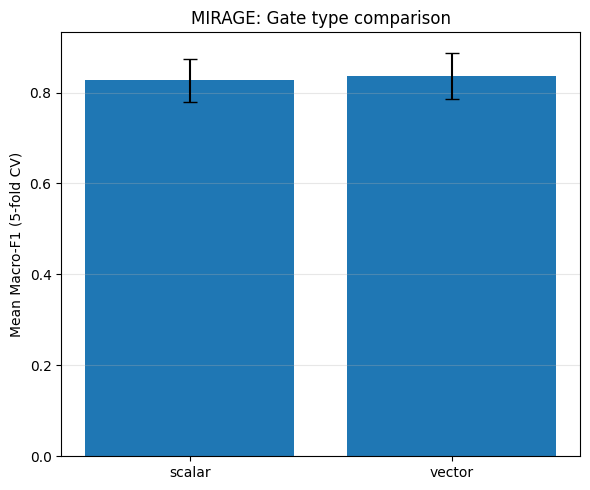

In [21]:
# Sweep 1: gate_type (scalar vs vector)
gate_type_results = []
for gate_type in ['scalar', 'vector']:
    mean_f1, std_f1, mean_acc, std_acc, _, _ = run_mirage_across_folds(
        gene_dim=500, path_dim=22, embed_dim=64, gene_hidden=128, path_hidden=32,
        dropout=0.2, lr=3e-4, weight_decay=1e-4, gate_type=gate_type
    )
    gate_type_results.append({'gate_type': gate_type, 'mean_macro_f1': mean_f1, 'std_macro_f1': std_f1,
                                'mean_accuracy': mean_acc, 'std_accuracy': std_acc})
    print(f"gate_type={gate_type}: macro-F1={mean_f1:.4f} (+/-{std_f1:.4f}), accuracy={mean_acc:.4f} (+/-{std_acc:.4f})")

gate_type_df = pd.DataFrame(gate_type_results)

plt.figure(figsize=(6, 5))
plt.bar(gate_type_df['gate_type'], gate_type_df['mean_macro_f1'], yerr=gate_type_df['std_macro_f1'], capsize=5)
plt.ylabel('Mean Macro-F1 (5-fold CV)')
plt.title('MIRAGE: Gate type comparison')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

embed=32 (gene_hidden=64, path_hidden=16): macro-F1=0.8237 (+/-0.0308), accuracy=0.8857 (+/-0.0184)
embed=64 (gene_hidden=128, path_hidden=32): macro-F1=0.8369 (+/-0.0512), accuracy=0.8841 (+/-0.0352)
embed=128 (gene_hidden=256, path_hidden=64): macro-F1=0.8453 (+/-0.0526), accuracy=0.8915 (+/-0.0249)


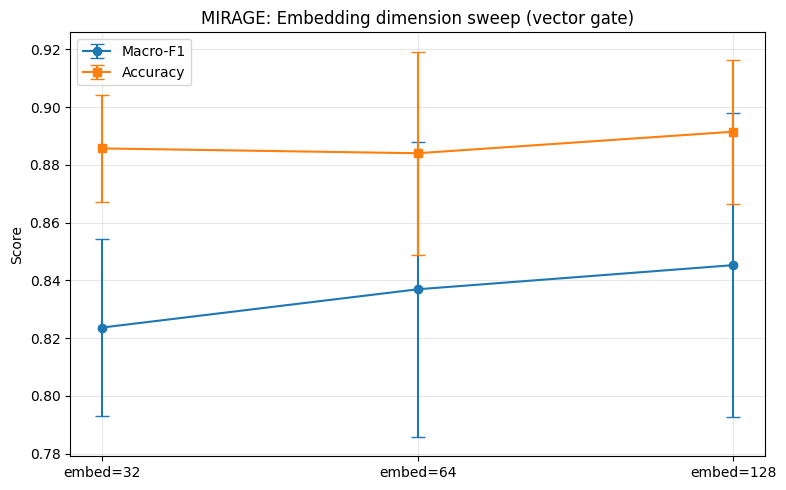

In [22]:
configs_to_test = [
    {'embed_dim': 32, 'gene_hidden': 64, 'path_hidden': 16},
    {'embed_dim': 64, 'gene_hidden': 128, 'path_hidden': 32},   # current baseline
    {'embed_dim': 128, 'gene_hidden': 256, 'path_hidden': 64},
]

embed_results = []
for cfg in configs_to_test:
    mean_f1, std_f1, mean_acc, std_acc, _, _ = run_mirage_across_folds(
        gene_dim=500, path_dim=22, embed_dim=cfg['embed_dim'],
        gene_hidden=cfg['gene_hidden'], path_hidden=cfg['path_hidden'],
        dropout=0.2, lr=3e-4, weight_decay=1e-4, gate_type='vector'
    )
    label = f"embed={cfg['embed_dim']}"
    embed_results.append({'config': label, 'mean_macro_f1': mean_f1, 'std_macro_f1': std_f1,
                           'mean_accuracy': mean_acc, 'std_accuracy': std_acc})
    print(f"{label} (gene_hidden={cfg['gene_hidden']}, path_hidden={cfg['path_hidden']}): "
          f"macro-F1={mean_f1:.4f} (+/-{std_f1:.4f}), accuracy={mean_acc:.4f} (+/-{std_acc:.4f})")

embed_df = pd.DataFrame(embed_results)

fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(embed_df['config'], embed_df['mean_macro_f1'], yerr=embed_df['std_macro_f1'], marker='o', capsize=5, label='Macro-F1')
ax.errorbar(embed_df['config'], embed_df['mean_accuracy'], yerr=embed_df['std_accuracy'], marker='s', capsize=5, label='Accuracy')
ax.set_ylabel('Score')
ax.set_title('MIRAGE: Embedding dimension sweep (vector gate)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

embed=128 (gh=256,ph=64): macro-F1=0.8453 (+/-0.0526), accuracy=0.8915 (+/-0.0249)
embed=256 (gh=512,ph=128): macro-F1=0.8356 (+/-0.0463), accuracy=0.8882 (+/-0.0273)
embed=256 (gh=384,ph=96): macro-F1=0.8478 (+/-0.0305), accuracy=0.8874 (+/-0.0205)


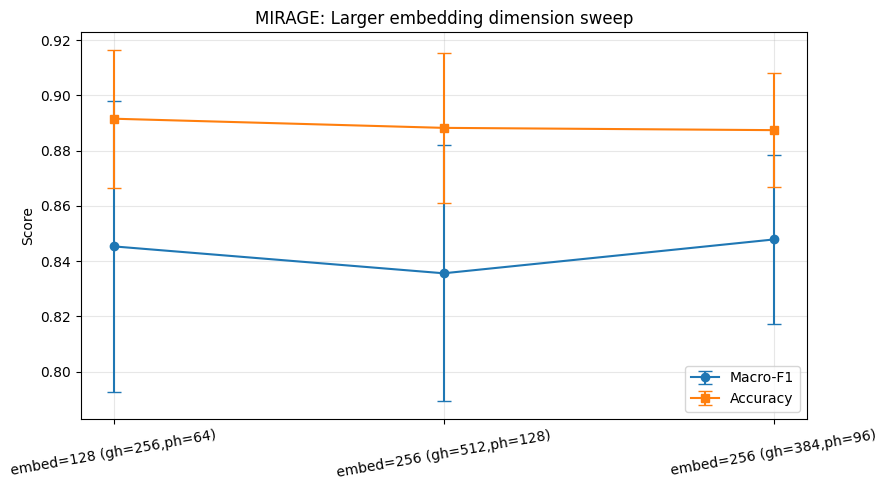

In [23]:
configs_to_test = [
    {'embed_dim': 128, 'gene_hidden': 256, 'path_hidden': 64},   # from before, for reference
    {'embed_dim': 256, 'gene_hidden': 512, 'path_hidden': 128},
    {'embed_dim': 256, 'gene_hidden': 384, 'path_hidden': 96},   # slightly less aggressive hidden scaling
]

embed_results_v2 = []
for cfg in configs_to_test:
    mean_f1, std_f1, mean_acc, std_acc, _, _ = run_mirage_across_folds(
        gene_dim=500, path_dim=22, embed_dim=cfg['embed_dim'],
        gene_hidden=cfg['gene_hidden'], path_hidden=cfg['path_hidden'],
        dropout=0.2, lr=3e-4, weight_decay=1e-4, gate_type='vector'
    )
    label = f"embed={cfg['embed_dim']} (gh={cfg['gene_hidden']},ph={cfg['path_hidden']})"
    embed_results_v2.append({'config': label, 'mean_macro_f1': mean_f1, 'std_macro_f1': std_f1,
                              'mean_accuracy': mean_acc, 'std_accuracy': std_acc})
    print(f"{label}: macro-F1={mean_f1:.4f} (+/-{std_f1:.4f}), accuracy={mean_acc:.4f} (+/-{std_acc:.4f})")

embed_v2_df = pd.DataFrame(embed_results_v2)

fig, ax = plt.subplots(figsize=(9, 5))
ax.errorbar(embed_v2_df['config'], embed_v2_df['mean_macro_f1'], yerr=embed_v2_df['std_macro_f1'], marker='o', capsize=5, label='Macro-F1')
ax.errorbar(embed_v2_df['config'], embed_v2_df['mean_accuracy'], yerr=embed_v2_df['std_accuracy'], marker='s', capsize=5, label='Accuracy')
ax.set_ylabel('Score')
ax.set_title('MIRAGE: Larger embedding dimension sweep')
ax.legend()
plt.xticks(rotation=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

embed=256,ratio=1.50 (gh=384,ph=96): macro-F1=0.8478 (+/-0.0305), accuracy=0.8874 (+/-0.0205)
embed=192,ratio=1.50 (gh=288,ph=72): macro-F1=0.8322 (+/-0.0457), accuracy=0.8874 (+/-0.0301)
embed=256,ratio=1.25 (gh=320,ph=80): macro-F1=0.8351 (+/-0.0475), accuracy=0.8932 (+/-0.0262)
embed=384,ratio=1.33 (gh=512,ph=128): macro-F1=0.8443 (+/-0.0466), accuracy=0.8940 (+/-0.0322)


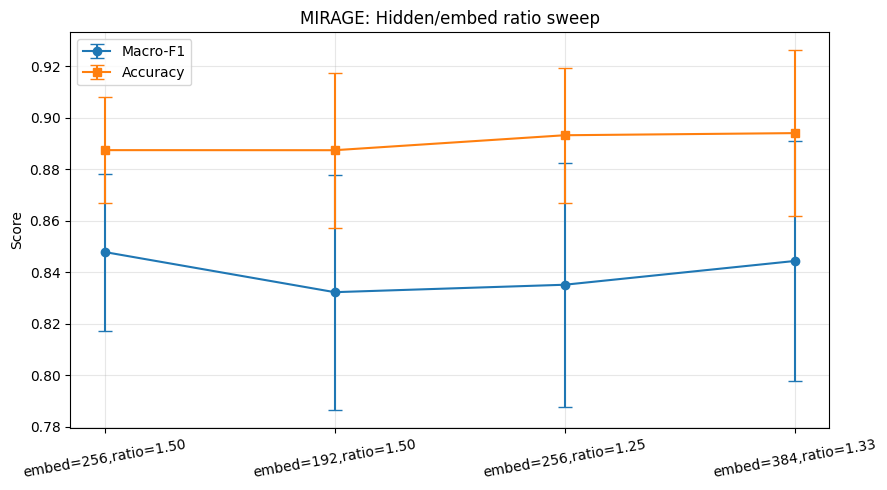

In [24]:
configs_to_test = [
    {'embed_dim': 256, 'gene_hidden': 384, 'path_hidden': 96},   # current best, for reference
    {'embed_dim': 192, 'gene_hidden': 288, 'path_hidden': 72},   # same ~1.5x ratio, smaller scale
    {'embed_dim': 256, 'gene_hidden': 320, 'path_hidden': 80},   # tighter ratio (~1.25x)
    {'embed_dim': 384, 'gene_hidden': 512, 'path_hidden': 128},  # same ratio, bigger scale
]

ratio_results = []
for cfg in configs_to_test:
    mean_f1, std_f1, mean_acc, std_acc, _, _ = run_mirage_across_folds(
        gene_dim=500, path_dim=22, embed_dim=cfg['embed_dim'],
        gene_hidden=cfg['gene_hidden'], path_hidden=cfg['path_hidden'],
        dropout=0.2, lr=3e-4, weight_decay=1e-4, gate_type='vector'
    )
    ratio = cfg['gene_hidden'] / cfg['embed_dim']
    label = f"embed={cfg['embed_dim']},ratio={ratio:.2f}"
    ratio_results.append({'config': label, 'mean_macro_f1': mean_f1, 'std_macro_f1': std_f1,
                           'mean_accuracy': mean_acc, 'std_accuracy': std_acc})
    print(f"{label} (gh={cfg['gene_hidden']},ph={cfg['path_hidden']}): "
          f"macro-F1={mean_f1:.4f} (+/-{std_f1:.4f}), accuracy={mean_acc:.4f} (+/-{std_acc:.4f})")

ratio_df = pd.DataFrame(ratio_results)

fig, ax = plt.subplots(figsize=(9, 5))
ax.errorbar(ratio_df['config'], ratio_df['mean_macro_f1'], yerr=ratio_df['std_macro_f1'], marker='o', capsize=5, label='Macro-F1')
ax.errorbar(ratio_df['config'], ratio_df['mean_accuracy'], yerr=ratio_df['std_accuracy'], marker='s', capsize=5, label='Accuracy')
ax.set_ylabel('Score')
ax.set_title('MIRAGE: Hidden/embed ratio sweep')
ax.legend()
plt.xticks(rotation=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

dropout=0.1: macro-F1=0.8403 (+/-0.0366), accuracy=0.8923 (+/-0.0245)
dropout=0.2: macro-F1=0.8478 (+/-0.0305), accuracy=0.8874 (+/-0.0205)
dropout=0.3: macro-F1=0.8436 (+/-0.0468), accuracy=0.8882 (+/-0.0271)
dropout=0.4: macro-F1=0.8296 (+/-0.0399), accuracy=0.8866 (+/-0.0212)


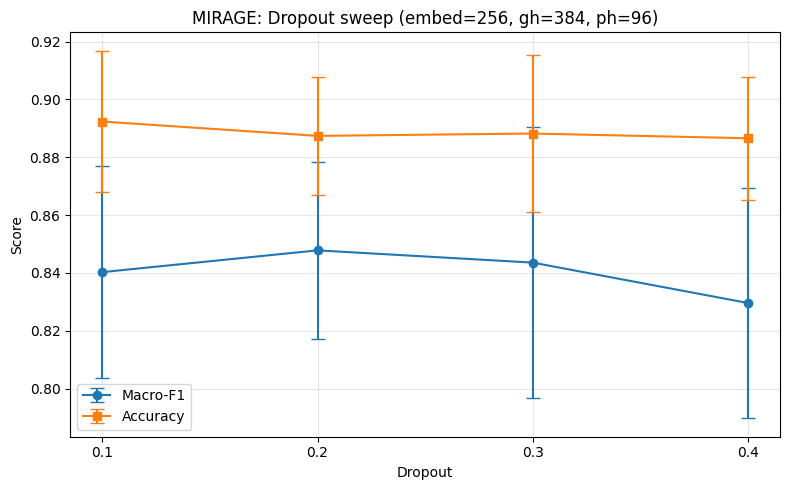

In [25]:
dropout_values_mirage = [0.1, 0.2, 0.3, 0.4]
dropout_mirage_results = []

for dropout in dropout_values_mirage:
    mean_f1, std_f1, mean_acc, std_acc, _, _ = run_mirage_across_folds(
        gene_dim=500, path_dim=22, embed_dim=256, gene_hidden=384, path_hidden=96,
        dropout=dropout, lr=3e-4, weight_decay=1e-4, gate_type='vector'
    )
    dropout_mirage_results.append({'dropout': dropout, 'mean_macro_f1': mean_f1, 'std_macro_f1': std_f1,
                                     'mean_accuracy': mean_acc, 'std_accuracy': std_acc})
    print(f"dropout={dropout}: macro-F1={mean_f1:.4f} (+/-{std_f1:.4f}), accuracy={mean_acc:.4f} (+/-{std_acc:.4f})")

dropout_mirage_df = pd.DataFrame(dropout_mirage_results)

fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(dropout_mirage_df['dropout'].astype(str), dropout_mirage_df['mean_macro_f1'],
            yerr=dropout_mirage_df['std_macro_f1'], marker='o', capsize=5, label='Macro-F1')
ax.errorbar(dropout_mirage_df['dropout'].astype(str), dropout_mirage_df['mean_accuracy'],
            yerr=dropout_mirage_df['std_accuracy'], marker='s', capsize=5, label='Accuracy')
ax.set_xlabel('Dropout')
ax.set_ylabel('Score')
ax.set_title('MIRAGE: Dropout sweep (embed=256, gh=384, ph=96)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [26]:
class GatedFusionMLPAux(nn.Module):
    def __init__(self, gene_dim, path_dim, embed_dim=256, gene_hidden=384, path_hidden=96,
                 dropout=0.2, num_classes=4, gate_type='vector'):
        super().__init__()
        self.gate_type = gate_type
        self.gene_encoder = ModalityEncoder(gene_dim, gene_hidden, embed_dim, dropout)
        self.path_encoder = ModalityEncoder(path_dim, path_hidden, embed_dim, dropout)

        gate_output_dim = 1 if gate_type == 'scalar' else embed_dim
        self.gate_net = nn.Sequential(
            nn.Linear(embed_dim * 2, 32),
            nn.ReLU(),
            nn.Linear(32, gate_output_dim),
            nn.Sigmoid()
        )

        self.classifier = nn.Sequential(
            nn.Linear(embed_dim, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, num_classes)
        )

        # NEW: auxiliary classifier heads, one per modality, applied directly to each embedding
        self.gene_aux_classifier = nn.Linear(embed_dim, num_classes)
        self.path_aux_classifier = nn.Linear(embed_dim, num_classes)

    def forward(self, gene_x, path_x, return_all=False):
        gene_emb = self.gene_encoder(gene_x)
        path_emb = self.path_encoder(path_x)

        gate_input = torch.cat([gene_emb, path_emb], dim=1)
        gate = self.gate_net(gate_input)

        fused = gate * gene_emb + (1 - gate) * path_emb
        main_logits = self.classifier(fused)

        if return_all:
            gene_aux_logits = self.gene_aux_classifier(gene_emb)
            path_aux_logits = self.path_aux_classifier(path_emb)
            gate_val = gate.squeeze(-1) if self.gate_type == 'scalar' else gate
            return main_logits, gene_aux_logits, path_aux_logits, gate_val
        return main_logits


def train_mirage_aux_fold(fold, gene_dim, path_dim, embed_dim, gene_hidden, path_hidden, dropout, lr, weight_decay,
                           aux_weight, gate_type='vector', epochs=300, patience=25, seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)

    gene_train_t = torch.tensor(fold_data[fold]['gene_train_mirage'].values, dtype=torch.float32)
    gene_val_t = torch.tensor(fold_data[fold]['gene_val_mirage'].values, dtype=torch.float32)
    path_train_t = torch.tensor(fold_data[fold]['path_train'].values, dtype=torch.float32)
    path_val_t = torch.tensor(fold_data[fold]['path_val'].values, dtype=torch.float32)

    y_train_enc = le.transform(fold_data[fold]['y_train'])
    y_val_enc = le.transform(fold_data[fold]['y_val'])
    y_train_t = torch.tensor(y_train_enc, dtype=torch.long)

    class_weights = compute_class_weight('balanced', classes=np.arange(4), y=y_train_enc)
    class_weights_t = torch.tensor(class_weights, dtype=torch.float32).to(device)

    g = torch.Generator()
    g.manual_seed(seed)
    train_ds = TensorDataset(gene_train_t, path_train_t, y_train_t)
    train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, generator=g)

    model = GatedFusionMLPAux(gene_dim, path_dim, embed_dim, gene_hidden, path_hidden, dropout,
                               gate_type=gate_type).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.CrossEntropyLoss(weight=class_weights_t)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=8)

    gene_val_dev = gene_val_t.to(device)
    path_val_dev = path_val_t.to(device)

    best_val_f1, best_state, epochs_no_improve = -1, None, 0

    for epoch in range(epochs):
        model.train()
        for gb, pb, yb in train_loader:
            gb, pb, yb = gb.to(device), pb.to(device), yb.to(device)
            optimizer.zero_grad()
            main_logits, gene_aux_logits, path_aux_logits, _ = model(gb, pb, return_all=True)

            main_loss = criterion(main_logits, yb)
            gene_aux_loss = criterion(gene_aux_logits, yb)
            path_aux_loss = criterion(path_aux_logits, yb)
            loss = main_loss + aux_weight * (gene_aux_loss + path_aux_loss)

            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            val_logits = model(gene_val_dev, path_val_dev)
            val_preds = val_logits.argmax(dim=1).cpu().numpy()
        val_f1 = f1_score(y_val_enc, val_preds, average='macro')
        scheduler.step(val_f1)

        if val_f1 > best_val_f1:
            best_val_f1, best_state, epochs_no_improve = val_f1, {k: v.clone() for k, v in model.state_dict().items()}, 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                break

    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        final_preds_enc = model(gene_val_dev, path_val_dev).argmax(dim=1).cpu().numpy()
    final_preds = le.inverse_transform(final_preds_enc)
    acc = accuracy_score(fold_data[fold]['y_val'], final_preds)

    return best_val_f1, acc, final_preds, fold_data[fold]['y_val']


aux_weights = [0.0, 0.1, 0.3, 0.5]
aux_results = []

for aux_w in aux_weights:
    fold_f1s, fold_accs = [], []
    for fold in range(5):
        val_f1, acc, preds, y_val = train_mirage_aux_fold(
            fold, gene_dim=500, path_dim=22, embed_dim=256, gene_hidden=384, path_hidden=96,
            dropout=0.2, lr=3e-4, weight_decay=1e-4, aux_weight=aux_w, gate_type='vector'
        )
        fold_f1s.append(val_f1)
        fold_accs.append(acc)
    mean_f1, std_f1 = np.mean(fold_f1s), np.std(fold_f1s)
    mean_acc, std_acc = np.mean(fold_accs), np.std(fold_accs)
    aux_results.append({'aux_weight': aux_w, 'mean_macro_f1': mean_f1, 'std_macro_f1': std_f1,
                         'mean_accuracy': mean_acc, 'std_accuracy': std_acc})
    print(f"aux_weight={aux_w}: macro-F1={mean_f1:.4f} (+/-{std_f1:.4f}), accuracy={mean_acc:.4f} (+/-{std_acc:.4f})")

print(f"\nCompare to no-aux baseline (aux_weight=0.0 above should roughly match): macro-F1=0.8478")

aux_weight=0.0: macro-F1=0.8478 (+/-0.0305), accuracy=0.8874 (+/-0.0205)
aux_weight=0.1: macro-F1=0.8497 (+/-0.0352), accuracy=0.8915 (+/-0.0238)
aux_weight=0.3: macro-F1=0.8396 (+/-0.0475), accuracy=0.8932 (+/-0.0281)
aux_weight=0.5: macro-F1=0.8229 (+/-0.0577), accuracy=0.8824 (+/-0.0242)

Compare to no-aux baseline (aux_weight=0.0 above should roughly match): macro-F1=0.8478


In [27]:
# Final MIRAGE run with locked config, storing predictions AND gate values
mirage_final_predictions = []
mirage_final_gates = []
mirage_final_f1s = []

for fold in range(5):
    torch.manual_seed(42)
    np.random.seed(42)

    gene_train_t = torch.tensor(fold_data[fold]['gene_train_mirage'].values, dtype=torch.float32)
    gene_val_t = torch.tensor(fold_data[fold]['gene_val_mirage'].values, dtype=torch.float32)
    path_train_t = torch.tensor(fold_data[fold]['path_train'].values, dtype=torch.float32)
    path_val_t = torch.tensor(fold_data[fold]['path_val'].values, dtype=torch.float32)

    y_train_enc = le.transform(fold_data[fold]['y_train'])
    y_val_enc = le.transform(fold_data[fold]['y_val'])
    y_train_t = torch.tensor(y_train_enc, dtype=torch.long)

    class_weights = compute_class_weight('balanced', classes=np.arange(4), y=y_train_enc)
    class_weights_t = torch.tensor(class_weights, dtype=torch.float32).to(device)

    g = torch.Generator()
    g.manual_seed(42)
    train_ds = TensorDataset(gene_train_t, path_train_t, y_train_t)
    train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, generator=g)

    model = GatedFusionMLPAux(gene_dim=500, path_dim=22, embed_dim=256, gene_hidden=384, path_hidden=96,
                               dropout=0.2, gate_type='vector').to(device)
    optimizer = optim.Adam(model.parameters(), lr=3e-4, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss(weight=class_weights_t)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=8)

    gene_val_dev = gene_val_t.to(device)
    path_val_dev = path_val_t.to(device)

    best_val_f1, best_state, epochs_no_improve = -1, None, 0

    for epoch in range(300):
        model.train()
        for gb, pb, yb in train_loader:
            gb, pb, yb = gb.to(device), pb.to(device), yb.to(device)
            optimizer.zero_grad()
            main_logits, gene_aux_logits, path_aux_logits, _ = model(gb, pb, return_all=True)
            loss = criterion(main_logits, yb) + 0.1 * (criterion(gene_aux_logits, yb) + criterion(path_aux_logits, yb))
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            val_preds = model(gene_val_dev, path_val_dev).argmax(dim=1).cpu().numpy()
        val_f1 = f1_score(y_val_enc, val_preds, average='macro')
        scheduler.step(val_f1)

        if val_f1 > best_val_f1:
            best_val_f1, best_state, epochs_no_improve = val_f1, {k: v.clone() for k, v in model.state_dict().items()}, 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= 25:
                break

    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        _, _, _, gate_vals = model(gene_val_dev, path_val_dev, return_all=True)
        final_preds_enc = model(gene_val_dev, path_val_dev).argmax(dim=1).cpu().numpy()
    final_preds = le.inverse_transform(final_preds_enc)

    mirage_final_predictions.append((fold_data[fold]['y_val'], final_preds))
    mirage_final_gates.append(gate_vals.cpu().numpy())
    mirage_final_f1s.append(best_val_f1)

all_y_true_mirage = np.concatenate([p[0] for p in mirage_final_predictions])
all_y_pred_mirage = np.concatenate([p[1] for p in mirage_final_predictions])

print(f"Final MIRAGE: mean macro-F1={np.mean(mirage_final_f1s):.4f}, "
      f"accuracy={accuracy_score(all_y_true_mirage, all_y_pred_mirage):.4f}")
print("\nPer-class report:")
print(classification_report(all_y_true_mirage, all_y_pred_mirage, zero_division=0))

model_results['MIRAGE'] = {
    'mean_macro_f1': np.mean(mirage_final_f1s),
    'std_macro_f1': np.std(mirage_final_f1s),
    'predictions': mirage_final_predictions,
    'gate_values': mirage_final_gates,
    'best_params': {'embed_dim': 256, 'gene_hidden': 384, 'path_hidden': 96, 'dropout': 0.2,
                     'lr': 3e-4, 'weight_decay': 1e-4, 'gate_type': 'vector', 'aux_weight': 0.1}
}

with open(f'{DATA_DIR}/classical_baseline_results.pkl', 'wb') as f:
    pickle.dump(model_results, f)
print("\nSaved MIRAGE results.")

Final MIRAGE: mean macro-F1=0.8497, accuracy=0.8916

Per-class report:
              precision    recall  f1-score   support

        ABMR       0.83      0.85      0.84       326
       Mixed       0.85      0.85      0.85        27
          NR       0.94      0.92      0.93       774
        TCMR       0.75      0.81      0.78        81

    accuracy                           0.89      1208
   macro avg       0.84      0.86      0.85      1208
weighted avg       0.89      0.89      0.89      1208


Saved MIRAGE results.


In [28]:
from sklearn.metrics import roc_auc_score, confusion_matrix
from sklearn.preprocessing import label_binarize

# Rebuild MIRAGE with the locked config, this time saving full probability distributions per sample
mirage_all_probs = []
mirage_all_true = []
mirage_all_gates = []
mirage_all_gsms = []

for fold in range(5):
    torch.manual_seed(42)
    np.random.seed(42)

    gene_train_t = torch.tensor(fold_data[fold]['gene_train_mirage'].values, dtype=torch.float32)
    gene_val_t = torch.tensor(fold_data[fold]['gene_val_mirage'].values, dtype=torch.float32)
    path_train_t = torch.tensor(fold_data[fold]['path_train'].values, dtype=torch.float32)
    path_val_t = torch.tensor(fold_data[fold]['path_val'].values, dtype=torch.float32)

    y_train_enc = le.transform(fold_data[fold]['y_train'])
    y_val_enc = le.transform(fold_data[fold]['y_val'])
    y_train_t = torch.tensor(y_train_enc, dtype=torch.long)

    class_weights = compute_class_weight('balanced', classes=np.arange(4), y=y_train_enc)
    class_weights_t = torch.tensor(class_weights, dtype=torch.float32).to(device)

    g = torch.Generator()
    g.manual_seed(42)
    train_ds = TensorDataset(gene_train_t, path_train_t, y_train_t)
    train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, generator=g)

    model = GatedFusionMLPAux(gene_dim=500, path_dim=22, embed_dim=256, gene_hidden=384, path_hidden=96,
                               dropout=0.2, gate_type='vector').to(device)
    optimizer = optim.Adam(model.parameters(), lr=3e-4, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss(weight=class_weights_t)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=8)

    gene_val_dev = gene_val_t.to(device)
    path_val_dev = path_val_t.to(device)

    best_val_f1, best_state, epochs_no_improve = -1, None, 0

    for epoch in range(300):
        model.train()
        for gb, pb, yb in train_loader:
            gb, pb, yb = gb.to(device), pb.to(device), yb.to(device)
            optimizer.zero_grad()
            main_logits, gene_aux_logits, path_aux_logits, _ = model(gb, pb, return_all=True)
            loss = criterion(main_logits, yb) + 0.1 * (criterion(gene_aux_logits, yb) + criterion(path_aux_logits, yb))
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            val_preds = model(gene_val_dev, path_val_dev).argmax(dim=1).cpu().numpy()
        val_f1 = f1_score(y_val_enc, val_preds, average='macro')
        scheduler.step(val_f1)

        if val_f1 > best_val_f1:
            best_val_f1, best_state, epochs_no_improve = val_f1, {k: v.clone() for k, v in model.state_dict().items()}, 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= 25:
                break

    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        main_logits, _, _, gate_vals = model(gene_val_dev, path_val_dev, return_all=True)
        val_probs = torch.softmax(main_logits, dim=1).cpu().numpy()

    mirage_all_probs.append(val_probs)
    mirage_all_true.extend(fold_data[fold]['y_val'])
    mirage_all_gates.append(gate_vals.cpu().numpy())
    mirage_all_gsms.extend(fold_data[fold]['val_gsms'] if 'val_gsms' in fold_data[fold] else clean_df.loc[clean_df['cv_fold']==fold, 'GSM'].values)

# Concatenate everything across folds
all_probs = np.vstack(mirage_all_probs)  # shape (1208, 4)
all_true = np.array(mirage_all_true)
all_gates = np.vstack(mirage_all_gates)  # shape (1208, embed_dim) since vector gate
all_gsms = np.array(mirage_all_gsms)

class_order = le.classes_  # order matches softmax output columns
print("Class order (matches probability columns):", class_order)
print("all_probs shape:", all_probs.shape)

# --- AUROC (one-vs-rest, macro-averaged) ---
y_true_binarized = label_binarize(all_true, classes=class_order)
auroc_macro = roc_auc_score(y_true_binarized, all_probs, average='macro', multi_class='ovr')
auroc_per_class = roc_auc_score(y_true_binarized, all_probs, average=None, multi_class='ovr')

print(f"\nMacro AUROC: {auroc_macro:.4f}")
for cls, auc in zip(class_order, auroc_per_class):
    print(f"  {cls}: AUROC={auc:.4f}")

# --- Confusion matrix ---
all_preds = class_order[all_probs.argmax(axis=1)]
cm = confusion_matrix(all_true, all_preds, labels=class_order)
cm_df = pd.DataFrame(cm, index=[f'true_{c}' for c in class_order], columns=[f'pred_{c}' for c in class_order])
print("\nConfusion matrix:")
print(cm_df)

# --- Save everything needed for Phase 14 (uncertainty) ---
mirage_full_results = {
    'probs': all_probs, 'true_labels': all_true, 'gates': all_gates, 'gsms': all_gsms,
    'class_order': class_order, 'auroc_macro': auroc_macro, 'auroc_per_class': dict(zip(class_order, auroc_per_class)),
    'confusion_matrix': cm_df
}

with open(f'{DATA_DIR}/mirage_full_results.pkl', 'wb') as f:
    pickle.dump(mirage_full_results, f)
print(f"\nSaved full MIRAGE results (probabilities, gates, GSMs) to mirage_full_results.pkl")

Class order (matches probability columns): ['ABMR' 'Mixed' 'NR' 'TCMR']
all_probs shape: (1208, 4)

Macro AUROC: 0.9737
  ABMR: AUROC=0.9591
  Mixed: AUROC=0.9920
  NR: AUROC=0.9670
  TCMR: AUROC=0.9768

Confusion matrix:
            pred_ABMR  pred_Mixed  pred_NR  pred_TCMR
true_ABMR         277           1       43          5
true_Mixed          1          23        0          3
true_NR            49           0      711         14
true_TCMR           7           3        5         66

Saved full MIRAGE results (probabilities, gates, GSMs) to mirage_full_results.pkl
